In [1]:
!pip install google-cloud-vision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 538.2/538.2 kB 9.3 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from google.cloud import vision

In [9]:
def detect_text(path):
    """Detects text in the file."""
    from google.cloud import vision

    client = vision.ImageAnnotatorClient()

    with open(path, "rb") as image_file:
        content = image_file.read()

    image = vision.Image(content=content)

    response = client.text_detection(image=image)
    texts = response.text_annotations
    print("Texts:")

    for text in texts:
        print(f'\n"{text.description}"')

        vertices = [
            f"({vertex.x},{vertex.y})" for vertex in text.bounding_poly.vertices
        ]

        print("bounds: {}".format(",".join(vertices)))

    if response.error.message:
        raise Exception(
            "{}\nFor more info on error messages, check: "
            "https://cloud.google.com/apis/design/errors".format(response.error.message)
        )
    
    return response,texts


In [10]:
response, texts = detect_text("/Users/ineshtandon/Documents/GitHub/NeoBio-CV_Pipeline/testing output images/ocr_prep_debug/test14_stitched.png")

Texts:

"Human Liver
Mouse Liver
rEPO/1367
Rat Liver
Hamster Liver
Guinea pig Liver
Rabbit Liver"
bounds: (447,7),(981,7),(981,411),(447,411)

"Human"
bounds: (447,260),(522,163),(542,178),(467,275)

"Liver"
bounds: (529,154),(581,87),(601,102),(549,169)

"Mouse"
bounds: (517,258),(587,169),(608,186),(538,275)

"Liver"
bounds: (594,161),(645,96),(666,112),(614,177)

"rEPO"
bounds: (562,385),(655,385),(655,411),(562,411)

"/"
bounds: (656,385),(668,385),(668,411),(656,411)

"1367"
bounds: (670,385),(750,385),(750,411),(670,411)

"Rat"
bounds: (594,258),(628,214),(648,230),(615,274)

"Liver"
bounds: (634,206),(685,140),(706,155),(655,222)

"Hamster"
bounds: (670,260),(762,141),(783,158),(691,276)

"Liver"
bounds: (767,136),(818,69),(839,85),(788,152)

"Guinea"
bounds: (742,261),(817,165),(842,185),(767,281)

"pig"
bounds: (824,156),(856,115),(881,135),(849,176)

"Liver"
bounds: (862,109),(913,44),(938,63),(887,129)

"Rabbit"
bounds: (818,259),(886,173),(908,190),(840,276)

"Liver"
bounds

In [17]:
type(str(response))

str

In [18]:
print(response)

text_annotations {
  locale: "en"
  description: "Human Liver\nMouse Liver\nrEPO/1367\nRat Liver\nHamster Liver\nGuinea pig Liver\nRabbit Liver"
  bounding_poly {
    vertices {
      x: 447
      y: 7
    }
    vertices {
      x: 981
      y: 7
    }
    vertices {
      x: 981
      y: 411
    }
    vertices {
      x: 447
      y: 411
    }
  }
}
text_annotations {
  description: "Human"
  bounding_poly {
    vertices {
      x: 447
      y: 260
    }
    vertices {
      x: 522
      y: 163
    }
    vertices {
      x: 542
      y: 178
    }
    vertices {
      x: 467
      y: 275
    }
  }
}
text_annotations {
  description: "Liver"
  bounding_poly {
    vertices {
      x: 529
      y: 154
    }
    vertices {
      x: 581
      y: 87
    }
    vertices {
      x: 601
      y: 102
    }
    vertices {
      x: 549
      y: 169
    }
  }
}
text_annotations {
  description: "Mouse"
  bounding_poly {
    vertices {
      x: 517
      y: 258
    }
    vertices {
      x: 587
     

In [12]:
print(texts)

[locale: "en"
description: "Human Liver\nMouse Liver\nrEPO/1367\nRat Liver\nHamster Liver\nGuinea pig Liver\nRabbit Liver"
bounding_poly {
  vertices {
    x: 447
    y: 7
  }
  vertices {
    x: 981
    y: 7
  }
  vertices {
    x: 981
    y: 411
  }
  vertices {
    x: 447
    y: 411
  }
}
, description: "Human"
bounding_poly {
  vertices {
    x: 447
    y: 260
  }
  vertices {
    x: 522
    y: 163
  }
  vertices {
    x: 542
    y: 178
  }
  vertices {
    x: 467
    y: 275
  }
}
, description: "Liver"
bounding_poly {
  vertices {
    x: 529
    y: 154
  }
  vertices {
    x: 581
    y: 87
  }
  vertices {
    x: 601
    y: 102
  }
  vertices {
    x: 549
    y: 169
  }
}
, description: "Mouse"
bounding_poly {
  vertices {
    x: 517
    y: 258
  }
  vertices {
    x: 587
    y: 169
  }
  vertices {
    x: 608
    y: 186
  }
  vertices {
    x: 538
    y: 275
  }
}
, description: "Liver"
bounding_poly {
  vertices {
    x: 594
    y: 161
  }
  vertices {
    x: 645
    y: 96
  }
 

In [20]:
with open("response.txt", "w") as file:
    file.write(str(response))
    file.write("\n")

## Testing Top Crop Rotation

Top crop rotation to horizontally align individual agent names to mitigate multi block agent name breakdown problem currently present in rotated image.

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def rotate_image_bound(image: np.ndarray, angle_deg: float, border_value=(255, 255, 255)) -> np.ndarray:
    """
    Rotate an image without cropping its contents.
    Positive angle = counter-clockwise rotation.
    """
    h, w = image.shape[:2]
    center = (w / 2.0, h / 2.0)

    M = cv2.getRotationMatrix2D(center, angle_deg, 1.0)

    cos = abs(M[0, 0])
    sin = abs(M[0, 1])

    new_w = int((h * sin) + (w * cos))
    new_h = int((h * cos) + (w * sin))

    M[0, 2] += (new_w / 2.0) - center[0]
    M[1, 2] += (new_h / 2.0) - center[1]

    rotated = cv2.warpAffine(
        image,
        M,
        (new_w, new_h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=border_value,
    )
    return rotated


def pad_to_width(image: np.ndarray, target_width: int, pad_value=255) -> np.ndarray:
    """
    Pad image on left/right to match target width.
    """
    h, w = image.shape[:2]
    if w == target_width:
        return image

    total_pad = target_width - w
    left_pad = total_pad // 2
    right_pad = total_pad - left_pad

    if image.ndim == 2:
        return cv2.copyMakeBorder(
            image, 0, 0, left_pad, right_pad,
            borderType=cv2.BORDER_CONSTANT,
            value=pad_value
        )
    else:
        return cv2.copyMakeBorder(
            image, 0, 0, left_pad, right_pad,
            borderType=cv2.BORDER_CONSTANT,
            value=(pad_value, pad_value, pad_value)
        )


def build_rotated_top_stitched_image(
    image_bgr: np.ndarray,
    roi: tuple,
    *,
    top_extra_bottom_px: int = 6,
    bottom_extra_top_px: int = 6,
    top_rotation_deg: float = 52.0,
    gap_px: int = 20,
    gap_value: int = 255,
):
    """
    Parameters
    ----------
    image_bgr : np.ndarray
        Original BGR image.
    roi : tuple
        (x1, y1, x2, y2) in full-image coordinates.
        Only y1 and y2 are used here.
    top_extra_bottom_px : int
        Extend the top crop slightly downward into the ROI if needed.
    bottom_extra_top_px : int
        Extend the bottom crop slightly upward into the ROI if needed.
    top_rotation_deg : float
        Angle to rotate ONLY the top crop.
        Positive angle = counter-clockwise.
    gap_px : int
        Vertical white separator between top and bottom stitched regions.
    gap_value : int
        Background value for separator/padding.

    Returns
    -------
    dict with:
        top_crop
        top_rotated
        bottom_crop
        stitched
        stitch_boundary_y
        top_bounds
        bottom_bounds
    """
    if image_bgr is None or image_bgr.size == 0:
        raise ValueError("image_bgr is empty or invalid.")

    if len(roi) != 4:
        raise ValueError("roi must be a 4-tuple: (x1, y1, x2, y2)")

    h, w = image_bgr.shape[:2]
    _, roi_y1, _, roi_y2 = roi

    roi_y1 = int(np.clip(roi_y1, 0, h))
    roi_y2 = int(np.clip(roi_y2, 0, h))

    top_y1 = 0
    top_y2 = int(np.clip(roi_y1 + top_extra_bottom_px, 0, h))

    bottom_y1 = int(np.clip(roi_y2 - bottom_extra_top_px, 0, h))
    bottom_y2 = h

    if top_y2 <= top_y1:
        raise ValueError(f"Top crop is empty. Computed bounds: {(0, top_y1, w, top_y2)}")
    if bottom_y2 <= bottom_y1:
        raise ValueError(f"Bottom crop is empty. Computed bounds: {(0, bottom_y1, w, bottom_y2)}")

    top_crop = image_bgr[top_y1:top_y2, 0:w].copy()
    bottom_crop = image_bgr[bottom_y1:bottom_y2, 0:w].copy()

    top_rotated = rotate_image_bound(top_crop, top_rotation_deg, border_value=(gap_value, gap_value, gap_value))

    target_width = max(top_rotated.shape[1], bottom_crop.shape[1])
    top_rotated_padded = pad_to_width(top_rotated, target_width, pad_value=gap_value)
    bottom_crop_padded = pad_to_width(bottom_crop, target_width, pad_value=gap_value)

    if image_bgr.ndim == 2:
        gap = np.full((gap_px, target_width), gap_value, dtype=image_bgr.dtype)
    else:
        gap = np.full((gap_px, target_width, 3), gap_value, dtype=image_bgr.dtype)

    stitched = np.vstack([top_rotated_padded, gap, bottom_crop_padded])

    stitch_boundary_y = top_rotated_padded.shape[0]

    return {
        "top_crop": top_crop,
        "top_rotated": top_rotated_padded,
        "bottom_crop": bottom_crop_padded,
        "stitched": stitched,
        "stitch_boundary_y": stitch_boundary_y,
        "top_bounds": (0, top_y1, w, top_y2),
        "bottom_bounds": (0, bottom_y1, w, bottom_y2),
    }

In [27]:
from pathlib import Path
import sys
# Resolve project root and add its src/ directory to sys.path
project_root = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "neobio").exists()),
    None,
)
if project_root is None:
    raise ModuleNotFoundError("Could not find 'src/neobio' from the current notebook location.")

src_path = str(project_root / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from neobio.blot.lane_mask import build_lane_mask, roi_from_mask
# _ = (build_lane_mask, roi_from_mask)

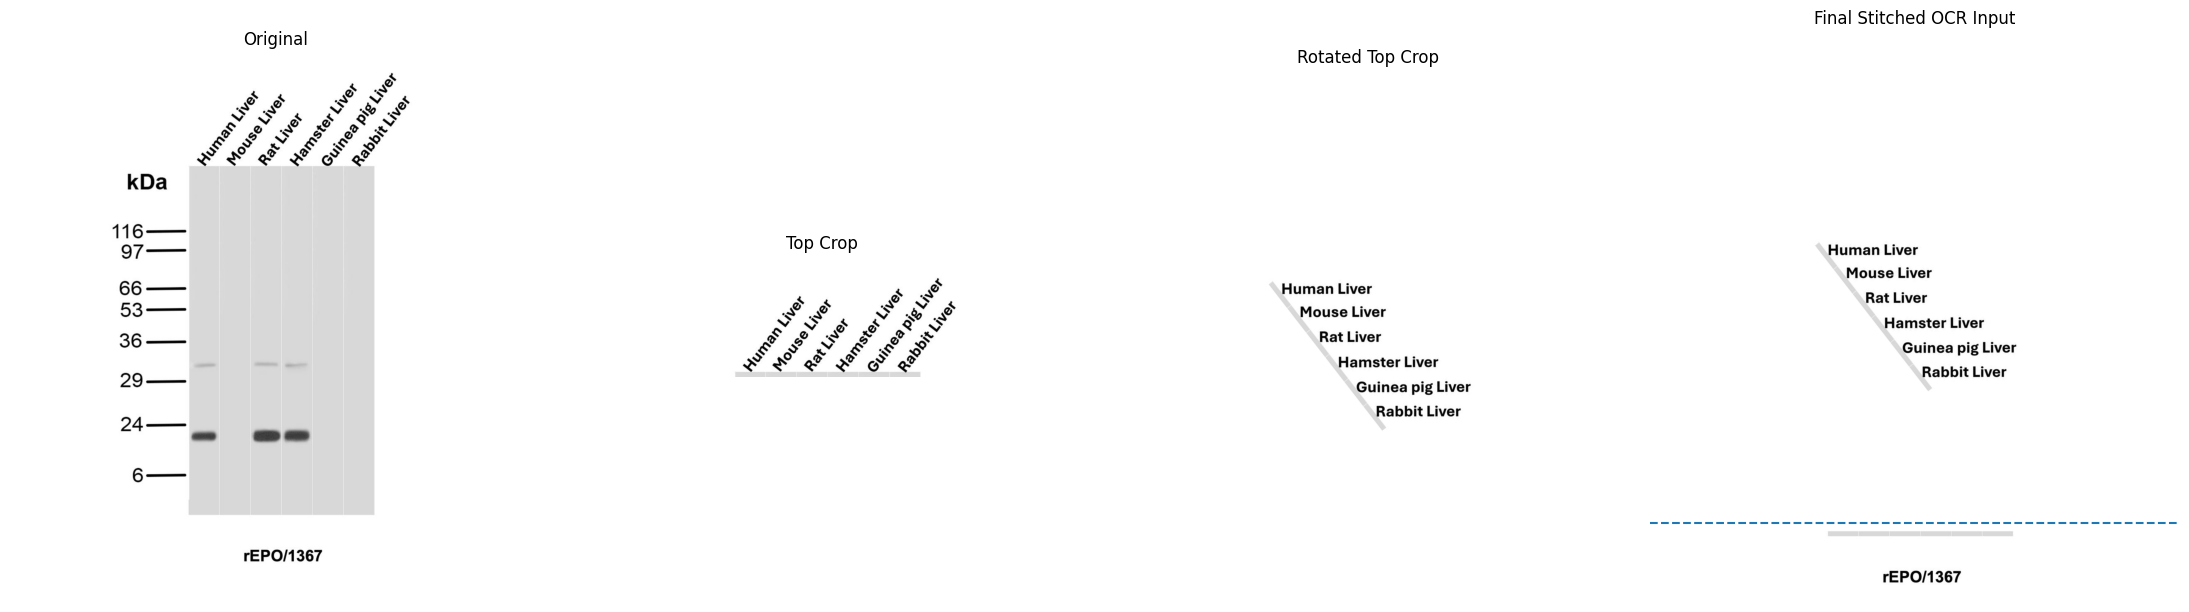

Top bounds: (0, 0, 1280, 287)
Bottom bounds: (0, 1103, 1280, 1274)
Stitch boundary y: 1187


In [37]:

# -------------------------
# Example usage
# -------------------------

# 1) Load image
image_path = "/Users/ineshtandon/Documents/GitHub/NeoBio-CV_Pipeline/NeoBio Input Images/test14.jpeg"
image_bgr = cv2.imread(image_path)
if image_bgr is None:
    raise FileNotFoundError(f"Could not read image: {image_path}")

# 2) Put your ROI here from the blot pipeline
#    Format: (x1, y1, x2, y2)
#    Replace this example with your real ROI.
roi = roi_from_mask(build_lane_mask(image_bgr))

# 3) Build stitched OCR input
result = build_rotated_top_stitched_image(
    image_bgr,
    roi,
    top_extra_bottom_px=10,
    bottom_extra_top_px=10,
    top_rotation_deg=-52.2,   # try 48, 50, 52, 54, 56 if needed
    gap_px=20,
    gap_value=255,
)

stitched_bgr = result["stitched"]

# 4) Save if you want
# output_path = "/testing output images/ocr_prep_debug/test14_rotated_top_stitched.png"
# cv2.imwrite(output_path, stitched_bgr)
cv2.imwrite('./rotation_test.png',stitched_bgr)

# 5) Show results
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

axes[0].imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")

axes[1].imshow(cv2.cvtColor(result["top_crop"], cv2.COLOR_BGR2RGB))
axes[1].set_title("Top Crop")

axes[2].imshow(cv2.cvtColor(result["top_rotated"], cv2.COLOR_BGR2RGB))
axes[2].set_title("Rotated Top Crop")

axes[3].imshow(cv2.cvtColor(stitched_bgr, cv2.COLOR_BGR2RGB))
axes[3].axhline(result["stitch_boundary_y"], linestyle="--")
axes[3].set_title("Final Stitched OCR Input")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

print("Top bounds:", result["top_bounds"])
print("Bottom bounds:", result["bottom_bounds"])
print("Stitch boundary y:", result["stitch_boundary_y"])
# print("Saved to:", output_path)

In [38]:
response, texts = detect_text("/Users/ineshtandon/Documents/GitHub/NeoBio-CV_Pipeline/notebooks/rotation_test.png")

Texts:

"Human Liver
Mouse Liver
Rat Liver
Hamster Liver
Guinea pig Liver
Rabbit Liver
rEPO/1367"
bounds: (430,515),(886,515),(886,1330),(430,1330)

"Human"
bounds: (430,515),(553,515),(553,539),(430,539)

"Liver"
bounds: (565,515),(648,515),(648,539),(565,539)

"Mouse"
bounds: (474,570),(588,570),(588,596),(474,596)

"Liver"
bounds: (598,570),(683,570),(683,596),(598,596)

"Rat"
bounds: (520,629),(577,629),(577,654),(520,654)

"Liver"
bounds: (586,629),(670,628),(670,652),(586,653)

"Hamster"
bounds: (566,690),(715,690),(715,715),(566,715)

"Liver"
bounds: (725,690),(807,690),(807,715),(725,715)

"Guinea"
bounds: (610,751),(732,751),(732,780),(610,780)

"pig"
bounds: (742,751),(793,751),(793,780),(742,780)

"Liver"
bounds: (803,751),(886,751),(886,780),(803,780)

"Rabbit"
bounds: (658,809),(769,809),(769,834),(658,834)

"Liver"
bounds: (779,809),(863,809),(863,834),(779,834)

"rEPO"
bounds: (562,1304),(654,1304),(654,1330),(562,1330)

"/"
bounds: (656,1304),(668,1304),(668,1330),(656,

In [39]:
with open("response.txt", "w") as file:
    file.write(str(response))
    file.write("\n")